# Music Blog Content Generation with LangGraph

## Overview

This notebook implements an agent-based system for the automatic generation of music blog posts using **LangGraph**, a framework for building modular and dynamic language agent workflows.  
The system combines the power of LLMs with a graph-based architecture to structure and manage the entire editorial pipeline.

## Objectives

- Automate the creation of thematic blog content related to music.
- Ensure topic diversity, coherence, and relevance.
- Allow active human participation in the content review process.
- Maintain a memory of previously used topics to avoid repetition.
- Plan Future Topics and Post Scheduling for the Next Publication.

## How It Works

The workflow is built as a directed graph, where each **node** corresponds to a specific task in the pipeline.  
Key components include:

- **Topic classification**: Determines whether a topic is user-provided or needs to be suggested.
- **Resource retrieval**: Searches for informative and trustworthy content.
- **Evaluation and selection**: Assesses sources and selects the most relevant one using an LLM.
- **Draft generation**: Composes a blog draft based on the selected topic and resource.
- **Human-in-the-loop review**: Lets the user approve or request changes to the draft.
- **Conditional routing**: Adapts the flow depending on user feedback (rewrite, change topic/resource).
- **Post logging and planning**: Stores completed posts and suggests future topics periodically.

By leveraging a modular structure, the system ensures adaptability, traceability, and control, supporting both automation and editorial supervision.

In [1]:
%%capture --no-stderr
%pip install --quiet -U langchain_openai langchain_core langgraph langgraph-prebuilt

### Installing `langchain_community`

The command `pip install langchain_community` is used to install the `langchain_community` library, which provides a collection of community-driven tools and components that extend the functionality of the LangChain framework.

#### Purpose:
- **Extend LangChain**: The library adds community-contributed modules that enhance LangChain with additional features.
- **Enhance Functionality**: It includes integrations, utilities, and other components that are helpful for building applications using language models.
- **Community Contributions**: This library brings together tools developed by the LangChain user community to address specific needs that may not be covered in the core LangChain library.

By installing `langchain_community`, you gain access to a variety of additional resources that can help improve and expand your LangChain-based applications.

In [2]:
pip install langchain_community

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 24.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.4/44.4 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 3.8 MB/s eta 0:00:00


In [ ]:
from typing import Annotated, Optional
from langgraph.graph.message import add_messages
from typing_extensions import Literal
from pydantic import BaseModel, Field
from typing import List
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langgraph.graph import START, StateGraph, END
from langgraph.checkpoint.memory import MemorySaver
from langchain_openai import ChatOpenAI
from IPython.display import Image, display
import json
import os, getpass, random
import asyncio
from langchain_community.tools.tavily_search import TavilySearchResults
from langgraph.types import interrupt, Command
import re
from langgraph.store.memory import InMemoryStore
import uuid, datetime



openai_api_key = ""
tavily_api_key = ""
os.environ["OPENAI_API_KEY"] = openai_api_key
os.environ["TAVILY_API_KEY"] = tavily_api_key


llm = ChatOpenAI(model="gpt-3.5-turbo")

Shared State: `MessagesState`

This data model defines the shared state passed between nodes in the LangGraph flow. It captures all relevant context and memory needed to coordinate agents and manage the editorial process.

- `messages`: The conversation history, used to maintain continuity and provide context to the LLM.
- `post_type`: The type of post to generate (e.g., "how-to", "event", "review"). Can be set manually or inferred.
- `topic`: The current topic under discussion or generation.
- `completed_topics`: A list of all topics that have already been used, to avoid repetition.
- `completed_posts`: A list of generated posts. Each entry is a dictionary containing the `topic` and the generated `draft`.
- `resources_candidates`: A list of all retrieved resources (e.g., from a web search) relevant to the topic.
- `selected_resource`: The most appropriate resource selected for content generation.
- `excluded_resources`: A list of URLs or sources to exclude from future searches (e.g., low-quality or already used).
- `decision`: Stores decisions or actions taken during the flow, useful for traceability and logic.
- `next_node`: Specifies the next node in the graph, enabling dynamic routing.
- `previous_draft`: Stores the last draft version in case a rewrite is requested.
- `revision_note`: Contains feedback or specific instructions from the human reviewer (e.g., what to improve or change).


In [4]:
# stato da passare al modello

class MessagesState(BaseModel):
    messages: Annotated[List, add_messages]

    post_type: Optional[Literal["how-to", "event", "review"]] = None
    topic: Optional[str] = None
    # Storico dei post completati
    completed_topics: List[str] = []
    completed_posts: List[dict] = []  # ogni dict = {"topic": ..., "draft": ...}

    resources_candidates: Optional[List[dict]] = None   # lista completa
    selected_resource:   Optional[dict]       = None    # la migliore

    excluded_resources: List[str] = []

    decision: List[str] = Field(default_factory=list)
    next_node: Optional[str] = None  # Campo aggiunto per gestire il nodo successivo
    previous_draft: Optional[str] = None
    revision_note: Optional[str] = None


### Memory Access Detection and Post Planning

This section defines two key components for managing memory access and controlling the post planning loop.

- `total_posts = 2`  
  Sets the number of blog posts to be generated in the current session. This parameter helps the planner determine how many cycles to run.

---

#### `is_show_memories_request(state: MessagesState) -> bool`

This asynchronous function determines whether the user wants to access their previously generated posts (memories).

It uses a **language model prompt** (`check_prompt`) that:
- Interprets the user's last message.
- Classifies it based on intent:
  - If the user asks to "see", "show", "retrieve", or "browse" **previous posts or memories**, the model should respond `"sì"`.
  - Otherwise, it should respond `"no"`.

The model is instructed to **only return a single word**, `"sì"` or `"no"`, avoiding any explanations.  
This ensures clean and deterministic routing behavior in the agent's logic.


In [5]:
total_posts = 2  # Numero di post da pianificare nel flusso

async def is_show_memories_request(state: MessagesState) -> bool:
    user_input = state.messages[-1].content

    check_prompt = ChatPromptTemplate.from_messages([
    ("system",
     "Sei un router che deve riconoscere se l'utente vuole vedere i suoi post o le sue memorie passate.\n\n"
     "– Se l'utente chiede di **vedere, mostrare, recuperare, sfogliare** i suoi **post scritti precedentemente**, le sue **memorie**, oppure i **contenuti già prodotti**, devi rispondere **'sì'**.\n\n"
     "– In tutti gli altri casi devi rispondere **'no'**.\n\n"
     "❗️ Ignora formule di cortesia e dettagli accessori (es. 'per favore', 'potresti', 'vorrei sapere').\n"
     "Concentrati sull'intenzione principale:\n"
     "  - Se vuole **vedere contenuti passati** → **sì**\n"
     "  - Se chiede **altro** (idee nuove, scrivere nuovi post, consigli, ecc.) → **no**\n\n"
     "⚠️ Rispondi **solo** con una parola: **sì** oppure **no**. Nessuna spiegazione, nessun'altra parola."
    ),
    ("human", "{user_input}")
])

    response = await (check_prompt | llm).ainvoke({"user_input": user_input})
    return response.content.strip().lower() == "sì"


Only a single-word response is expected from the model to ensure robust and deterministic routing.

Trusted Domains Check: `is_trusted`

This helper function checks whether a given link originates from a list of **pre-approved, reliable domains**, such as:
- `rollingstone.com`
- `soundonsound.com`
- `musicradar.com`
- `pitchfork.com`
- `splice.com`
- `theverge.com`
- `wired.com`

This is used during resource evaluation to ensure content quality and credibility.

Refined Search Prompt: `refine_search`

A prompt template that transforms the current blog topic and any revision instructions (e.g., from a human reviewer) into a **more precise web search query**. This is used when initial resources are inadequate or when the user requests alternative content angles.

The runnable `refine_search_runnable` combines the prompt with the LLM, ready for invocation.

In [6]:

trusted_domains = [
    "rollingstone.com",
    "soundonsound.com",
    "musicradar.com",
    "pitchfork.com",
    "splice.com",
    "theverge.com",
    "wired.com"
]


def is_trusted(link: str) -> bool:
    return any(domain in link for domain in trusted_domains)


refine_search = ChatPromptTemplate.from_messages([
  ("system", "Sei un assistente che trasforma un argomento di blog e un feedback in una query di ricerca web più mirata."),
  ("human", "Argomento: {topic}\nIstruzione utente: {revision_note}\n\nGenera una nuova query di ricerca.")
])

refine_search_runnable = refine_search | llm

### Router Functionality for Blog Content

This section defines the functionality of a **router** that decides the appropriate next step in the music blog content generation process. The router classifies user input into two categories: **generic** or **specific**, based on the presence of a topic or specific request.

---

#### Router Prompt Template

The **router prompt** uses a **ChatPromptTemplate** to determine if the user's request is generic or specific. The template follows these rules:

- **Generic Request**: If the user asks for **advice**, **ideas**, or **inspiration** without providing a specific topic (e.g., "give me a post idea" or "suggest blog topics"), it returns **'generica'**.
- **Specific Request**: If the user provides a **topic** (e.g., "write about new music genres" or "post about Spotify vs Apple Music"), it returns **'specifico'**.

---

#### Router Function

The **router function** processes user input and classifies it according to the above rules. Based on this classification, it routes the flow to the appropriate next step:

- If the request is **generic**, it moves to the **Topic Suggester**.
- If the request is **specific**, it moves to the **Input Classifier Node**.

Additionally, it checks if the user wants to see their previously created posts or memories. If the request is about **past posts**, the flow will route to **ShowMemories**.

---

#### Router Condition and Flow Control

The **router condition** checks the current state to determine the next node in the flow. If the state is a dictionary, it retrieves the `next_node` key. If it's a state object, it checks the `next_node` attribute. By default, it suggests the **Topic Suggester** node.

The **should_continue** function evaluates whether to continue based on whether a **selected resource** exists. If a resource is selected, the function returns **'Pass'**, otherwise, it returns **'Fail'**.


In [7]:
router_prompt = ChatPromptTemplate.from_messages([
  ("system",
   "Sei un router per un assistente di blog musicale.\n"
   "Devi rispondere **'generica'** o **'specifico'** a seconda che l'utente:\n\n"
   "– chieda **consigli, idee o ispirazione** senza indicare alcun argomento preciso (es. “consigliami un post”, “idee per un articolo”, “suggeriscimi argomenti da trattare”),\n"
   "  in questo caso restituisci **'generica'**;\n\n"
   "– fornisca invece **qualunque tipo di tema**, anche espresso in termini generali (es. “generi emergenti”, “come registrare a casa”, “post su Spotify vs Apple Music”),\n"
   "  in questo caso restituisci **'specifico'**.\n\n"
   "❗️ Ignora le formule di cortesia (“scrivimi un post”, “vorrei una guida”). Concentrati su verbo+oggetto:\n"
   "  - Se l’azione è “consiglia/idee/suggerisci” **senza tema** → **generica**\n"
   "  - Se l’azione è “scrivi/posta/pubblica” **con un tema** → **specifico**\n"
   "  - **Se menzioni un tipo di contenuto** (articolo, post, video) **su** un argomento (es. “articolo su top 3 artisti italiani”) → **specifico**\n\n"
   "⚠️ Rispondi **solo** con la parola **specifico** o **generica**. Niente spiegazioni."
  ),
  ("human", "{user_input}")
])



async def router(state: MessagesState):

    user_input = state.messages[-1].content

    if await is_show_memories_request(state):
        return MessagesState(messages=state.messages, next_node="ShowMemories")


    response = await (router_prompt | llm).ainvoke({"user_input": user_input})

    classification = response.content.strip().lower()
    if "generica" in classification:
        next_node = "Topic_suggester"
    else:
        next_node = "input_classifier_node"

    return MessagesState(messages=state.messages, next_node=next_node)


def router_condition(state):
    if isinstance(state, dict):
        return state.get("next_node", "Topic_suggester")

    return state.next_node or "Topic_suggester"


def should_continue(state: MessagesState):
    ### print("✅ should_continue - selected_resource:", state.selected_resource)

    return "Pass" if state.selected_resource else "Fail"

### Topic Suggester Node

The **Topic Suggester Node** is responsible for generating relevant and fresh blog post ideas based on current trends in the music industry. It works by:

1. **Generating Diverse Topics**: The system suggests at least 5 blog topics related to music. These topics cover various aspects of the music world, including emerging genres, cultural movements, music festivals, production tools, technology trends, and industry news.
   - **Avoiding Repetition**: It ensures that none of the suggested topics are similar to the ones already covered, based on the `completed_topics` list. This prevents redundant or semantically similar suggestions.
   - **Unique Topics**: It also ensures that topics are not just rephrased versions of previous ones.

2. **Selecting the Best Topic**: After generating a list of topics, the system chooses the most interesting and relevant one, which is then classified under one of three post types:
   - **'how-to'**
   - **'event'**
   - **'review'**

3. **Explaining the Choice**: The system provides a brief explanation of why the selected topic was chosen, helping to clarify the reasoning behind the decision.

4. **Output Format**: The result is returned as a plain JSON object, containing the following structure:
   - `topic`: The title of the selected blog post.
   - `post_type`: The type of post (either 'how-to', 'event', or 'review').
   - `reason`: A short explanation of why this topic was chosen.
   - `candidates`: A list of the generated topic ideas.



**get_all_completed_topics_from_memory**

Utility function to retrieve all previously approved topics from the long-term memory (`in_memory_store`). This allows the system to avoid suggesting or reusing topics that have already been used in previous blog posts — even across sessions.  It returns a list of topic titles stored under the given namespace.

In [8]:
def get_all_completed_topics_from_memory(namespace) -> List[str]:
    entries: dict = in_memory_store._data.get(namespace, {})
    return [itm.value["topic"] for itm in entries.values() if "topic" in itm.value]

In [9]:
topic_suggester_prompt = ChatPromptTemplate.from_messages([
    ("system",
     "You are a topic suggestion assistant for a music-themed blog.\n"
     "Your task is to:\n"
     "1. Generate a list of at least 5 diverse and trending blog post topics related to music.\n"
     "   - Cover different angles: emerging genres, cultural movements, festivals/events, production tools, tech trends, industry news.\n"
     "   - ❗️Avoid repeating any of these previously used topics (including similar or paraphrased versions): {completed_topics}.\n"
     "   - Avoid suggesting topics that are semantically similar to the excluded ones, even if rephrased.\n"
     "     For example, if 'Top 3 Italian rappers' was already covered, do not suggest 'Best Italian hip hop artists' or 'Top rap acts from Italy'.\n"
     "2. Choose the single most interesting topic from your list (not in the excluded ones).\n"
     """3. Classify it into one of these post types:
    - 'how-to'
    - 'event'
    - 'review'
    ❗️Do NOT invent other types. Only choose from these three values."""
     "4. Explain briefly why you selected that specific topic.\n\n"
     "Respond ONLY with a plain JSON object using the following structure:\n"
     "{{\n"
     "  \"topic\": \"...\",            // the selected blog title\n"
     "  \"post_type\": \"...\",        // one of ['how-to', 'event', 'review']\n"
     "  \"reason\": \"...\",           // short explanation of why this topic was selected\n"
     "  \"candidates\": [\"...\", \"...\", \"...\", ...]  // list of generated topic ideas\n"
     "}}\n\n"
     "⚠️ Do not use markdown, backticks, or explanations outside the JSON. Only return valid JSON with double quotes.")
])



### Topic Suggester Node
async def Topic_suggester(state: MessagesState) -> MessagesState:

    completed = get_all_completed_topics_from_memory(namespace_memories)

    response = await (topic_suggester_prompt | llm).ainvoke({"completed_topics": completed})
    print("🧠 Output Topic Suggester:\n", response.content)

    parsed = json.loads(response.content) if isinstance(response.content, str) else response.content

    topic = parsed["topic"]
    post_type = parsed["post_type"]
    reason = parsed.get("reason", "")
    candidates = parsed.get("candidates", [])

    # Visualizzazione su console
    print("\n📌 Topic selezionato:", topic)
    print("📂 Tipo di post:", post_type)
    print("💬 Motivo della scelta:", reason)
    print("🎯 Candidati generati:")
    for i, t in enumerate(candidates, 1):
        print(f"  {i}. {t}")

    return MessagesState(
        messages=state.messages,
        topic=parsed["topic"],
        post_type=parsed["post_type"],
    )

### Classifier Node

The **Classifier Node** is designed to classify the user's request for writing a blog post based on the content provided. It determines the type of blog post and extracts the core topic to create a clear and concise blog title. Here's how it works:

1. **Classifying the Post Type**: The system classifies the intended type of blog post based on the user's request. The possible post types are:
   - **'how-to'**
   - **'event'**
   - **'review'**

2. **Extracting the Topic**: The system then extracts the topic from the user request and rewrites it as a concise and clear blog title. This ensures that the topic is focused and relevant to the post.

3. **Response Format**: The system responds with a **plain JSON object** containing:
   - `post_type`: The classified type of the blog post (either 'how-to', 'event', or 'review').
   - `topic`: A concise and clear blog title that reflects the main topic of the post.

4. **Purpose**: This node helps organize user requests into actionable blog post formats, ensuring that each post is categorized correctly and has a clear, defined topic.


In [10]:
classifier_prompt = ChatPromptTemplate.from_messages([
    ("system",
     "You are an intent classifier for a music-themed blog assistant.\n"
     "Given a user request, you MUST pick exactly **one** of these post types:\n"
     "  • how-to\n"
     "  • event\n"
     "  • review\n"
     "- the topic, rewritten as a concise and clear blog title.\n\n"
     "Do not format your response as a code block. Return only plain JSON object with keys: 'post_type' and 'topic'."),
    ("human", "{user_input}")
])


# CLASSIFIER NODE
async def input_classifier_node(state: MessagesState) -> MessagesState:
    response = await (classifier_prompt | llm).ainvoke({"user_input": state.messages[-1].content})

    if isinstance(response.content, str):
      parsed = json.loads(response.content)
    else:
      parsed = response.content

    return MessagesState(
        messages=state.messages,
        post_type=parsed["post_type"],
        topic=parsed["topic"]
    )

### Resource Finder Node

The **Resource Finder Node** is a component of the system responsible for performing a web search to retrieve reliable resources based on the **topic** provided by the user. It uses the Tavily API to fetch search results and annotates the results with additional information, such as **trustworthiness** of the source.

#### Functionality:

1. **Input**:
   - The node receives the **topic** from the **MessagesState**. If a **revision_note** is provided, the search query is refined to be more targeted and precise.
   
2. **Query Refining**:
   - If a **revision_note** is provided, the `refine_search_runnable` prompt is used to refine the query, improving the search based on user feedback.

3. **Performing the Search**:
   - A search is executed using the Tavily module (`tavily.run(query)`) with either the refined or original query.
   - The search results are printed for monitoring.

4. **Annotating the Results**:
   - Each search result is annotated to determine if the associated link is a **trusted source**. This is determined by the `is_trusted` function, which checks if the domain of the link is in the list of trusted domains.

5. **Output**:
   - The annotated results, including the trustworthiness of the resources, are returned as a list of dictionaries containing the details of each result.

#### Annotated Results

Each search result contains:
   - The original result.
   - An additional field called **trusted**, indicating whether the link was considered reliable or not.


In [11]:
#tavily = TavilySearchResults(k=5)
tavily = TavilySearchResults(tavily_api_key="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", k=8)

async def resource_finder_node(state: MessagesState) -> MessagesState:

    query = state.topic

    if state.revision_note:
        refined = await refine_search_runnable.ainvoke({
            "topic": state.topic,
            "revision_note": state.revision_note
        })
        query = refined.content.strip()


    print("🔍 Query da utilizzare:", query)

    results = tavily.run(query)
    print("🔍 Risultati trovati:")
    for r in results:
        print(r)
    annotated_results = []


    for r in results:
        if isinstance(r, str):
            try:
                r_dict = json.loads(r)
            except Exception as e:
                ### print(f"Errore nel parsing del risultato: {e}")
                continue
        else:
            r_dict = r

        # Ora r_dict è un dizionario
        annotated = {**r_dict, "trusted": is_trusted(r_dict["url"])}
        annotated_results.append(annotated)


    return Command(update={
    "resources_candidates": annotated_results
    })

### Evaluator Node

This node evaluates a set of candidate resources for a music-themed blog, selecting the most suitable one based on quality, relevance, and trustworthiness. It is part of an asynchronous pipeline and uses structured prompts to produce a strict JSON output.

---

# Required Inputs

- `state.topic`: The current search topic.
- `state.resources_candidates`: A list of resources to be evaluated.
- `state.excluded_resources`: A list of URLs to exclude from evaluation.

---

# Evaluator Prompt

A `ChatPromptTemplate` using both system and human messages:

### System Prompt

Provides the model with detailed instructions:

- Filter out any URL found in `excluded_resources`.
- Evaluate each resource based on:
  - Clarity and usefulness of the content  
  - Relevance to the given topic  
  - Trust score (float between 0 and 1)  
  - Whether the source is considered "trusted" (based on a curated domain list)
- Select the **best** resource or return `"decision": "none"`.
- Return strict JSON:
  - No markdown, no quotes, no code formatting
  - Escape all non-ASCII characters using `\\uXXXX`
  - No trailing commas in objects or arrays

### Human Prompt

Contains the list of `resources` to be evaluated.

---

## Fallback Prompt for Topic Refinement

If no good resource is found (`"decision": "none"`), a fallback is triggered using `refinement_prompt`, which generates a refined Google search query (max 10 words, no quotes or explanations).


In [12]:
prompt_evaluator = ChatPromptTemplate.from_messages([
    ("system",
     "You are a content evaluator for a music-themed blog assistant.\n"
     "Escape any non‑ASCII characters as `\\uXXXX` and avoid `\\xYY` escapes.\n\n"
     "You will be given:\n"
     "  • A list of candidate resources about a specific topic\n"
     "  • A list of URLs to exclude: {excluded_resources}\n\n"
     "Before you begin evaluating, **filter out** any resource whose `url` appears in {excluded_resources}.\n\n"
     "Evaluate each resource based on:\n"
     "- 🔎 Clarity and usefulness of the content\n"
     "- 🎯 Relevance to the topic: {topic}\n"
     "- ✅ Trust score (a float from 0 to 1, higher is better)\n"
     "- 🔒 Whether the source is 'trusted' (based on a curated list of reliable domains)\n\n"
     "Instructions:\n"
     "1. Review the list of resources.\n"
     "2. Select the **best** one overall (considering quality + trust + score).\n"
     "3. If **none** are appropriate, return {{ \"decision\": \"none\" }}.\n\n"
     "Return a JSON object like:\n"
     "{{ \"decision\": \"use\", \"selected\": {{ \"url\": \"...\", \"content\": \"...\" }}, \"reason\": \"...\" }}\n"
     "or\n"
     "{{ \"decision\": \"none\" }}\n\n"
     "⚠️ Do not use markdown, backticks or code formatting. Just return plain JSON."
    "…🚨 STRICT JSON ONLY—escape all non-ASCII as \\uXXXX; do NOT use \\xNN escapes.\n"
    "❌ Do NOT include any trailing commas in objects or arrays.\n"
    ),
    ("human", "{resources}")
])


refinement_prompt = ChatPromptTemplate.from_messages([
    ("system", "Restituisci ESCLUSIVAMENTE una singola query di ricerca Google, max 10 parole, senza virgolette né spiegazioni."),
    ("human", "{topic}")
])

refine_topic_runnable = refinement_prompt | llm


async def evaluator_node(state: MessagesState) -> MessagesState:

  candidates = state.resources_candidates

  response = await (prompt_evaluator | llm).ainvoke({
    "topic": state.topic,
    "resources": candidates,
    "excluded_resources": state.excluded_resources
  })

  print("🧾 Output del modello evaluator:")
  print(response.content)

  raw = response.content

  # ———————————————————————————————————————————————
  # 1) Provo a fare il parsing diretto
  try:
    parsed = json.loads(raw)

  except json.JSONDecodeError:
    # 2) Sanificazione: rimuovo ogni "\" non seguito da uno degli escape JSON validi

    clean = re.sub(r'\\(?!["\\/bfnrtu])', '', raw)
    # 2) Rimuovo trailing commas prima di } o ]
    clean = re.sub(r',\s*(?=[}\]])', '', clean)
    # (ora riprovo il parsing)
    parsed = json.loads(clean)

  # 1) nulla di buono trovato → dirottiamo verso human_review
  if parsed["decision"] == "none":
    return Command(
        goto="resource_finder",
        update={
            "revision_note": (
                "La prima ricerca non ha dato risultati utili; "
                "prova una query più specifica (aggiungi anni, genere, premi, ecc.)."
            ),
            "selected_resource": None,
        }
    )

  # 2) fonte OK
  return Command(update={
      "selected_resource": parsed["selected"]
    })



### Assistant Node

The **Assistant Node** is responsible for generating an engaging blog post based on the selected resource. It either revises an existing draft (if `previous_draft` and `revision_note` are provided) or creates a new blog post from scratch using the topic and resource content.

#### Functionality:

1. **Input**:
   - The node receives:
     - `post_type`: The type of post to generate (e.g., 'event', 'how-to', 'review').
     - `topic`: The topic of the blog post.
     - `resource_content`: The content retrieved from the selected resource.
     - `resource_url`: The URL of the selected resource.
     - `previous_draft`: (optional) An existing draft of the blog post to be revised.
     - `revision_note`: (optional) Feedback for revising the previous draft.

2. **Instructions**:
   - If both `previous_draft` and `revision_note` are provided, the assistant revises the draft based on the feedback.
   - Otherwise, it generates a new blog post from scratch using the `topic` and `resource_content`.

3. **Tone and Structure**:
   - The post should have an **expressive, informative tone** that is suitable for music enthusiasts.
   - The content should be **concise and focused**, with a maximum of **600 words**.
   - The structure must follow a **single, clear sequence** without unnecessary complexity.
   - The post should **cite the source** naturally in the text or include the source link at the end.
   
4. **Post Type Instructions**:
   - **'event'**: Describe the event, location, what to expect, and why it's interesting.
   - **'how-to'**: Write a concise, step-by-step guide, including only the essential steps.
   - **'review'**: Evaluate the product or service fairly, including pros and cons.

In [13]:
assistant_prompt = ChatPromptTemplate.from_messages([
    ("system",
     "You are a blogging assistant for a music-themed blog.\n"
     "Your task is to write an engaging blog post using the selected `resource`.\n"
     "You must strictly rely on the information provided in the resource — do not invent content.\n\n"
     "Instructions:\n"
     "- If `previous_draft` and `revision_note` are provided, revise the existing draft based on the feedback.\n"
     "- Otherwise, generate a new blog post from scratch using the topic and resource.\n\n"
     "Structure and tone:\n"
     "- Use an expressive, informative tone suitable for music enthusiasts.\n"
     "- Keep the guide simple and straightforward, following a **single, clear sequence** of steps.\n"
     "- Avoid repeating steps or creating multiple lists. Stick to a logical, easy-to-follow order.\n"
     "- Include the source link at the end of the post (or cite it naturally in the text).\n"
     "- ⚡ Keep the post **concise and focused**, aiming for **no more than 600 words**.\n\n"
     "Instructions by post_type:\n"
     "- 'event': describe the event, location, what to expect, and why it's interesting.\n"
     "- 'how-to': write a concise, step-by-step guide that avoids unnecessary complexity. Only include the most essential steps.\n"
     "- 'review': evaluate the product/service fairly based on the resource. Include pros and cons."),

    ("human",
     "post_type: {post_type}\n"
     "topic: {topic}\n"
     "resource_content: {resource_content}\n"
     "resource_url: {resource_url}\n"
     "previous_draft: {previous_draft}\n"
     "revision_note: {revision_note}")
])


assistant_runnable = assistant_prompt | llm

async def assistant(state: MessagesState) -> Command:

  selected_resource = state.selected_resource

  previous_draft = getattr(state, "previous_draft", "")
  revision_note = getattr(state, "revision_note", "")

  response = await assistant_runnable.ainvoke({
      "post_type": state.post_type,
      "topic": state.topic,
      "resource_content": selected_resource["content"],
      "resource_url": selected_resource["url"],
      "previous_draft": previous_draft,
      "revision_note": revision_note
  })

  return Command(update={
    "messages": state.messages + [response],
    "decision": []              # 👈 lista vuota
    })

### Human Review Node

The **Human Review Node** is responsible for interacting with the user to get feedback on the draft generated in the previous steps. Based on the feedback, it either finalizes the post, requests a rewrite, or changes the resource used.

#### Functionality:

1. **Input**:
   - The node receives the current **draft** (the last generated content) and asks the user for feedback on whether to:
     - Approve and publish the draft.
     - Rewrite the draft.
     - Change the resource used for the draft.

2. **Feedback Options**:
   - **Approve**: If the user approves the draft, it is saved and added to the completed posts. The system then checks if all topics have been completed, either finishing the process or moving to the planner.
   - **Rewrite**: If the user requests a rewrite, they are prompted to provide feedback for revisions, and the system returns to the assistant for further refinement.
   - **Change Resource**: If the user wants to change the resource, the system excludes the current resource from future consideration, prompts for any revision notes, and returns to the resource finder to search for new sources.

#### Command Flow:

1. **Approval**:
   - Saves the draft with a unique ID and stores it in memory.
   - Updates the list of completed topics and posts.
   - If all topics are completed, the process ends (`END`). Otherwise, the flow continues to the **Planner**.

2. **Rewrite**:
   - The user is prompted to provide specific feedback for rewriting the draft.
   - Returns to the **Assistant** node for a new version of the blog post.

3. **Change Resource**:
   - Excludes the current resource from further consideration and asks if the user wants to add a revision note.
   - Returns to the **Resource Finder** to search for a new resource.

4. **Fallback**:
   - If the feedback is unclear or unrecognized, the system repeats the review process.


In [14]:
from langgraph.graph import END

def human_review(state: MessagesState) -> Command:

    draft = state.messages[-1].content
    feedback = interrupt({
        "question": "Review della bozza: approva / riscrivi / cambia fonte?",
        "draft": draft
    }).strip().lower()

    if feedback in ("approva", "approve", "pubblica", "publish"):

        key = str(uuid.uuid4())

        value = {
            "topic": state.topic,
            "draft": draft,
            "approved_at": datetime.datetime.utcnow().isoformat()
        }

        in_memory_store.put(namespace_memories, key, value)

        # aggiorno completed_topics e completed_posts
        new_completed = state.completed_topics + [state.topic]
        new_posts = state.completed_posts + [{"topic": state.topic, "draft": draft}]
        is_last = len(new_completed) >= total_posts

        return Command(
            update={
                "completed_topics": new_completed,
                "completed_posts": new_posts,
                "previous_draft": None,
                "revision_note": None,
                "messages": [],
                "topic": None,
                "selected_resource": None,
                "excluded_resources": []
            },
            goto=END if is_last else "Planner"
        )

    if feedback in ("riscrivi", "rewrite", "bozza"):
        note = interrupt("Inserisci le modifiche:")
        return Command(
            update={
                "previous_draft": draft,
                "revision_note": note,
                "selected_resource": state.selected_resource
            },
            goto="assistant"
        )

    if feedback in ("cambia fonte", "fonte", "change source", "risorsa"):

        current_url = state.selected_resource["url"]
        new_exclusions = list(set(state.excluded_resources + [current_url]))  # Elimina duplicati

        print(f"Esclusioni attive: {len(new_exclusions)}")
        print(f"Esclusioni attive: {new_exclusions}")

        want = interrupt({
            "question": "Vuoi inserire una nota di revisione per raffinare la ricerca? (sì/no)"
        }).strip().lower()

        if want in ("s", "si", "yes"):
            note = interrupt("Inserisci la tua nota di revisione:")
        else:
            note = None

        return Command(
            update={
                "excluded_resources": new_exclusions,
                "selected_resource": None,
                "revision_note": note
            },
            goto="resource_finder"
        )

    # fallback: ripeti human_review
    return Command(update={}, goto="human_review")


### Review Router Function

The **Review Router** is responsible for determining the next step in the workflow based on the user's decision after reviewing the content. It makes the decision to either proceed with further planning or finalize the process.

#### Functionality:

1. **Input**:
   - The node receives the **decision** from the user feedback, stored in the `state.decision` variable.

2. **Decision Handling**:
   - **Approve**:
     - If the feedback is "approve", the function checks whether all posts have been completed.
     - If not all posts are completed (`len(state.completed_posts) < total_posts`), it routes to the **Planner** to continue the process.
     - If all posts are completed, it routes to `END`, signaling the end of the process.
   
   - **Other Decisions**:
     - If the decision is something other than "approve", the function uses the `state.decision` directly to determine the next step in the flow.


In [15]:
def review_router(state: MessagesState):
    # Se l’ultimo feedback è “approve”, decidiamo qui se finire o ripianificare
    if state.decision == "approve":
        # se non ho ancora tutti i post, torno al Planner, altrimenti END
        return "Planner" if len(state.completed_posts) < total_posts else "END"
    # altrimenti uso la decisione come chiave diretta
    return state.decision

### Planner Function

The **Planner** function helps generate and manage blog post suggestions based on the editorial plan `total_posts` for a music-themed blog. It ensures that topics are not repeated and are engaging for the target audience.

#### Functionality:

1. **Input**:
   - The function receives the following parameters from the state:
     - `completed_topics`: A list of topics already covered in the blog.
     - `total_posts`: The total number of posts expected in the editorial plan.
   
2. **Processing**:
   - **Next Post Index**: The next post index is calculated as `next_idx = len(completed) + 1`.
   - **Topic Suggestion**: If there are still posts remaining to be planned (`next_idx <= total_posts`), the system generates a new blog post suggestion.
     - It ensures that the proposed topic hasn't been covered before, and avoids suggesting similar topics.

3. **Output**:
   - A **plain JSON object** containing:
     - `topic`: A clear and engaging title for the next blog post.
     - `post_type`: The type of the blog post, one of `['how-to', 'event', 'review']`.
     - `justification`: A brief explanation of why this topic was chosen.
   
4. **End of Plan**:
   - If all posts have been planned, the function returns a **no operation (noop)** command, meaning no changes will be made.


In [16]:
planner_prompt = ChatPromptTemplate.from_messages([
    ("system",
     "You are a content strategist assistant for a music-themed blog.\n"
     "Your task is to:\n"
     "1. Propose the next blog post (number {next_idx} out of {total}) in a weekly editorial plan.\n"
     "2. The blog has already covered these topics: {completed_topics}.\n"
     "   - Do not repeat any of them.\n"
     "   - Also avoid suggesting semantically similar or rephrased versions of the same topics.\n"
     "     For example, if 'Best DAWs for beginners' was covered, do not suggest 'Top entry-level music software'.\n"
     "3. For the new post, return a plain JSON object with:\n"
     "   - 'topic': a clear and engaging blog title\n"
     "   - 'post_type': one of ['how-to', 'event', 'review']\n"
     "❗️Do NOT invent other types. Only choose from these three values."
     "   - 'justification': a short sentence explaining why this topic was selected\n\n"
     "⚠️ Return ONLY a valid JSON object. Do NOT use markdown, backticks, or add explanations outside the JSON.")
])


async def Planner_node(state: MessagesState) -> Command | MessagesState:
    ### print("Sono nel planner\n")
    completed = get_all_completed_topics_from_memory(namespace_memories)
    next_idx = len(completed) + 1

    if next_idx > total_posts:
        # piano completato: nessun update
        return Command()          # noop

    # genera nuova proposta
    resp  = await (planner_prompt | llm).ainvoke({
        "completed_topics": completed,
        "next_idx": next_idx,
        "total": total_posts
    })
    item = json.loads(resp.content)

    # ⬇️  aggiorniamo SOLO i campi che cambiano
    return Command(update={
        "topic":       item["topic"],
        "post_type":   item["post_type"],
        "previous_draft": None
    })


The **ShowMemories** function retrieves and displays all saved memories from the in-memory store. It provides an overview of previously approved blog posts, including their topics, approval dates, and drafts.

#### Functionality:

1. **Input**:
   - The function does not require any external input; it works with the current `MessagesState`.

2. **Processing**:
   - **Retrieve Entries**: The function accesses all entries in the `memories` namespace using `in_memory_store._data.get(ns, {})`.
   - **Debugging**: It optionally prints a debug sample to inspect the contents of the entries.
   - **Extract Memories**: It loops through the entries and extracts the relevant information from each item (e.g., topic, approval date, and draft).

3. **Output**:
   - If no memories are found, it returns a message indicating that no memories are saved.
   - If memories are found, it returns a list of all saved posts, including:
     - The post's topic.
     - The approval date.
     - The draft content.

In [17]:
async def ShowMemories(state: MessagesState) -> Command:
    # 1) prendi tutte le entry nel namespace
    ns = ('1', 'memories')  # o usa direttamente namespace_memories
    entries: dict = in_memory_store._data.get(ns, {})

    # 2) debug rapido (opzionale)
    if entries:
        key, itm = next(iter(entries.items()))
        print(f"🔍 DEBUG sample Item: {key=}  {type(itm)=}  {dir(itm)=}")

    # 3) estrai i dict veri
    all_memories = []
    for itm in entries.values():
        rec = itm.value if hasattr(itm, "value") else itm
        all_memories.append(rec)

    # 4) compone il messaggio
    if not all_memories:
        msg = AIMessage(content="💡 Non ci sono memorie salvate al momento.")
    else:
        lines = []
        for i, m in enumerate(all_memories, start=1):
            titolo = m.get("topic", "–")
            data   = m.get("approved_at", "–")
            draft  = m.get("draft", "")
            lines.append(f"{i}. **{titolo}** – approvato il {data}\n{draft}\n")
        msg = AIMessage(content="Ecco tutti i post pubblicati finora:\n\n" + "\n".join(lines))

    return Command(update={"messages": state.messages + [msg]})


### Graph Definition for StateGraph

This section defines the state graph and the nodes involved in the process. The graph manages the flow of the blogging assistant, from topic suggestion to human review and approval.

#### Components:

1. **StateGraph**:
   - The `StateGraph` object manages the flow of states and transitions between them. It is instantiated with the `MessagesState` class.

2. **MemorySaver**:
   - The `MemorySaver` object is used to manage **short-term memory**, storing data like completed posts and topics during the current session.

3. **InMemoryStore**:
   - An in-memory store used for **long-term memory**, keeping data like previously generated content and topics across sessions.


4. **Nodes**:
   - The graph contains several nodes which represent different steps in the process. These nodes include:
     - **router**: Decides the next action based on current conditions.
     - **ShowMemories**: Displays previously published blog posts from memory.
     - **Topic_suggester**: Suggests topics for new blog posts.
     - **input_classifier_node**: Classifies input to determine the type of content.
     - **resource_finder**: Finds resources based on the selected topic.
     - **evaluator**: Evaluates the resources for their quality and relevance.
     - **assistant**: The blogging assistant that creates drafts based on resources.
     - **human_review**: A step for reviewing drafts and making decisions.
     - **Planner**: The content planning node that proposes the next post.

5. **Graph Edges**:
   - The nodes are connected by edges, representing the flow of decisions.
     - The flow starts from the `START` node and is routed to the `router`.
     - Based on the routing conditions, the flow can proceed to various nodes such as `ShowMemories`, `Topic_suggester`, or `input_classifier_node`.
     - From `Topic_suggester` or `input_classifier_node`, the flow continues to `resource_finder`.
     - After finding resources, the flow moves to the `evaluator`, which determines whether to continue with the assistant or re-check the resources.
     - Once the assistant generates a draft, it proceeds to `human_review` for feedback and revisions.
     - The planner node proposes new blog posts, guiding the entire flow.

6. **Conditional Edges**:
   - Conditional edges are used to control the flow based on certain conditions. For example, the `evaluator` node has conditions to either continue to `assistant` or go back to `resource_finder` if the resources are not sufficient.

7. **Memory Integration**:
   - The graph integrates memory through the `react_graph_memory`, which is a compiled version of the graph that includes a memory checkpointer to ensure persistent states during the flow.

8. **Interrupts**:
   - The graph includes `interrupt_before` to handle specific interrupts, such as before entering the `human_review` node.



In [18]:
builder = StateGraph(MessagesState)

memory = MemorySaver()

# In this case, we creates a configuration for a specific thread with ID '1'.
config = {"configurable": {"thread_id": "1"}}

# namespace_memories defines a unique namespace for storing information related to a specific user.
# In this case, a namespace for user ID '1' and the key 'memories' is created.
user_id = "1"
namespace_memories = (user_id, "memories")

# InMemoryStore is a temporary memory, used to store data in a volatile way (without long-term persistence).
in_memory_store = InMemoryStore()

builder.add_node("router", router)
builder.add_node("ShowMemories", ShowMemories)
builder.add_node("Topic_suggester", Topic_suggester)
builder.add_node("input_classifier_node", input_classifier_node)
builder.add_node("resource_finder", resource_finder_node)
builder.add_node("evaluator", evaluator_node)
builder.add_node("assistant", assistant)
builder.add_node("human_review", human_review)
builder.add_node("Planner", Planner_node)

#builder.add_edge(START, "input_classifier")
builder.add_edge(START, "router")

builder.add_conditional_edges(
    "router",
    router_condition,
    {
        "ShowMemories": "ShowMemories",
        "Topic_suggester": "Topic_suggester",
        "input_classifier_node": "input_classifier_node"
    }
)

builder.add_edge("Topic_suggester", "resource_finder")
builder.add_edge("input_classifier_node", "resource_finder")
builder.add_edge("resource_finder", "evaluator")
builder.add_conditional_edges(
    "evaluator",
    should_continue,
    {
        "Pass": "assistant",
        "Fail": "resource_finder",
        "__default__": "resource_finder"
    }
)


builder.add_edge("assistant", "human_review")

builder.add_edge("Planner", "resource_finder")

builder.add_edge("ShowMemories", END)

react_graph_memory = builder.compile(interrupt_before=["human_review"], checkpointer=memory)

### Visualizing the Graph with Mermaid

The following command generates a visual representation of the state graph using the Mermaid syntax. This helps to understand the flow and structure of the process.


In [19]:
print(react_graph_memory.get_graph(xray=False).draw_mermaid())


---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__(<p>__start__</p>)
	router(router)
	ShowMemories(ShowMemories)
	Topic_suggester(Topic_suggester)
	input_classifier_node(input_classifier_node)
	resource_finder(resource_finder)
	evaluator(evaluator)
	assistant(assistant)
	human_review(human_review<hr/><small><em>__interrupt = before</em></small>)
	Planner(Planner)
	__end__(<p>__end__</p>)
	Topic_suggester --> resource_finder;
	__start__ --> router;
	assistant --> human_review;
	evaluator -. &nbsp;Pass&nbsp; .-> assistant;
	evaluator -. &nbsp;__default__&nbsp; .-> resource_finder;
	input_classifier_node --> resource_finder;
	resource_finder --> evaluator;
	router -.-> ShowMemories;
	router -.-> Topic_suggester;
	router -.-> input_classifier_node;
	ShowMemories --> __end__;
	human_review --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



### Visualizing the Graph with an Image

The following command generates and displays a visual representation of the state graph in PNG format using the Mermaid syntax. This provides a graphical view of the flow and structure of your content generation process.

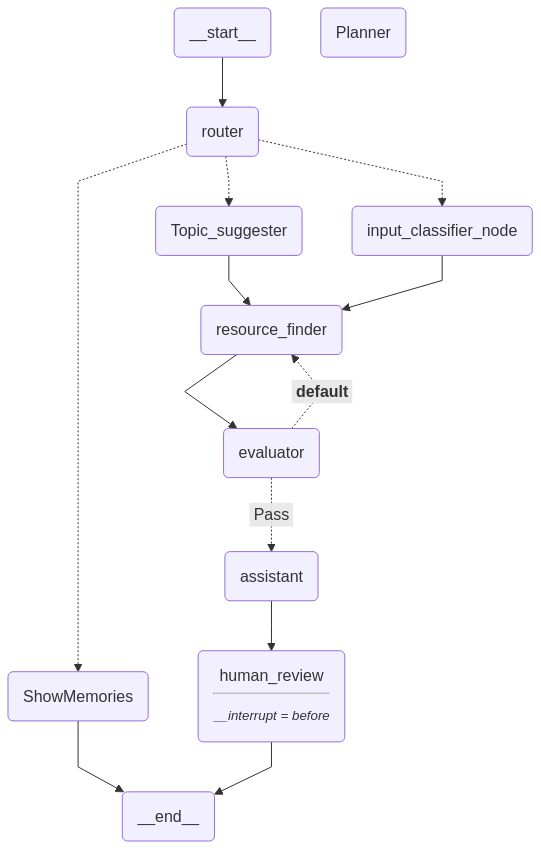

In [20]:
display(Image(react_graph_memory.get_graph(xray=False).draw_mermaid_png()))

### Blog Post Review and Finalization Process

This Python script defines the process of reviewing, revising, and finalizing blog drafts for a music-themed blog using a state graph. The flow includes user interaction for decision-making on drafts, source changes, and the option to add revision notes.

#### Key Components:

- **get_latest_draft**: A helper function to retrieve the most recent draft in the message sequence.
- **State Flow**: The script interacts with a state graph to drive the process of reviewing drafts and making decisions based on user input.
- **User Interaction**: The script prompts the user for input on whether to approve, rewrite, or change the source of a draft.

#### Flow Overview:

1. **Initial Launch**: The first message is a request from the user, which can either be a specific request  or a generic request.

If the user wants to show the posts, the state graph is triggered to process and display the current drafts.
   
2. **Review Loop**:
    - The user is presented with the latest draft.
    - The user can choose to approve, rewrite, or change the source.
    - If rewriting or changing the source, the user is prompted for additional revision notes or details.
    - The loop continues until all posts are completed.

3. **Final Output**:
    - Once all posts are completed, the script prints the final drafts that have been approved and published.



In [21]:
from langchain_core.messages import AIMessage, HumanMessage
from langgraph.types import Command

def get_latest_draft(state):
    for msg in reversed(state["messages"]):
        if isinstance(msg, AIMessage):
            return msg.content.strip()
    return ""

# 1️⃣ Lancio iniziale (ci fermiamo sul primo human_review)
messages = [HumanMessage(content="Recensione dell’ultimo album dei Radiohead")]
state = await react_graph_memory.ainvoke(
    {"messages": messages},
    config=config
)

msgs = state["messages"]
last = msgs[-1]

text = last.content if hasattr(last, "content") else last.get("content", "")

if state.get("topic") is None:
    # siamo in ShowMemories
    print(text)

else:
    # 2️⃣ Loop di review
    while len(state["completed_posts"]) < total_posts:
        draft = get_latest_draft(state)
        print("\n📝 Bozza corrente\n" + "-"*60 + "\n" + draft + "\n")

        azione = input("Che faccio?  [approva / riscrivi / cambia fonte] > ").strip().lower()

        if azione in ("approva", "approve", "pubblica", "publish"):
            state = await react_graph_memory.ainvoke(
                Command(resume="approva"),
                config=config
            )
            continue

        if azione in ("riscrivi", "rewrite", "bozza"):
            state = await react_graph_memory.ainvoke(
                Command(resume="riscrivi"),
                config=config
            )
            nota = input("✍️  Inserisci modifica:\n> ")
            state = await react_graph_memory.ainvoke(
                Command(resume=nota),
                config=config
            )
            continue

        if azione in ("cambia fonte", "fonte", "change source", "risorsa"):

            state = await react_graph_memory.ainvoke(
                Command(resume="cambia fonte"),
                config=config
            )
            want_note = input(
                {"question": "✍️ Vuoi inserire una nota di revisione per raffinare la ricerca? (sì/no)"}
            ).strip().lower()

            state = await react_graph_memory.ainvoke(
                Command(resume="s" if want_note in ("s","si","yes") else "no"),
                config=config,
            )

            if want_note in ("s", "si", "yes"):
                note = input({"question": "✍️ Inserisci la tua nota di revisione:"})
            else:
                note = ""

            state = await react_graph_memory.ainvoke(
                Command(resume=note),
                config=config
            )
            continue

        print("Comando non riconosciuto, riprova.")

    # 3️⃣ Stampa finale
    print("\n🏁 Flow terminato! Drafts pubblicati:\n")
    for post in state["completed_posts"]:
        print(f"— {post['topic']}\n{post['draft']}\n")


🔍 Query da utilizzare: Review of Radiohead's Latest Album
🔍 Risultati trovati:
{'title': "Radiohead's In Rainbows Album Review - Neirad", 'url': 'https://neirad.org/11928/pop-culture/radioheads-in-rainbows-album-review/', 'content': 'nerves on fire and to be frank, hearing the words for the first time, made me laugh out loud to myself. The band’s lyric choices in their tracks always manage to bury themselves within a special place in my heart through their mockery and satire. [...] belt that grips at the heartstrings and then almost caresses them to rest. A luminous lullaby hum that sways back and forth follows, and the song ends with a satisfying resolution. [...] All in all, it’s been a delectable array of songs to peck at for years and still remains to be due to not only its extraordinarily unique audios but its raw meaning. In all their years of producing music, Radiohead has never fallen short of creating albums and songs that go beyond the often heard shallow lyrics we get in mai